# Dependencies and Setup

In [9]:
# !pip install torch torchvision matplotlib tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Dataset Pipeline with Synthetic Segmentation and Actions

In [10]:
class ActionSegmentationFashionMNIST(Dataset):
    def __init__(self, train=True):
        # Load standard Fashion-MNIST scaled to [-1, 1]
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])
        self.base_dataset = torchvision.datasets.FashionMNIST(
            root='./data', train=train, download=True, transform=transform
        )
        
    def __len__(self):
        return len(self.base_dataset)
    
    def __getitem__(self, idx):
        img, label = self.base_dataset[idx]
        
        # 1. Generate a binary segmentation mask (1 for foreground object, 0 for background)
        mask = (img > -0.7).float()
        
        # 2. Generate a synthetic continuous action vector [shift_x, shift_y]
        # For demonstration, let action represent a target spatial shift mapping to the class
        random_action = torch.randn(2) 
        
        return img, mask, random_action, label

# Instantiate DataLoaders
train_dataset = ActionSegmentationFashionMNIST(train=True)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, drop_last=True)

# The Latent Space (Autoencoder Variational / Convolutional)

In [11]:
class LatentAutoencoder(nn.Module):
    """Compresses 28x28x1 image into a dense 7x7x4 latent space representation"""
    def __init__(self):
        super().__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1), # 14x14
            nn.ReLU(),
            nn.Conv2d(16, 4, kernel_size=3, stride=2, padding=1), # 7x7
            nn.ReLU()
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(4, 16, kernel_size=3, stride=2, padding=1, output_padding=1), # 14x14
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1), # 28x28
            nn.Tanh()
        )

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

# Pre-train or initialize the AE model
ae_model = LatentAutoencoder().to(device)

# Condition Encoders (Action & Segmentation)

In [12]:
class ActionEncoder(nn.Module):
    """Maps continuous 2D action tokens into cross-attention key/value spaces"""
    def __init__(self, action_dim=2, embed_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(action_dim, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, embed_dim)
        )
    def forward(self, action):
        # Returns shape: (Batch, 1, embed_dim) to mimic a token sequence
        return self.net(action).unsqueeze(1)

class SegmentationEncoder(nn.Module):
    """Downsamples spatial masks to align channel-wise with the latent space tensor"""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, stride=2, padding=1),  # 14x14
            nn.ReLU(),
            nn.Conv2d(8, 4, kernel_size=3, stride=2, padding=1),  # 7x7
            nn.ReLU()
        )
    def forward(self, mask):
        return self.net(mask)

# Sinusoidal Timestep Embeddings

In [13]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = np.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

# Latent Conditioned U-Net (The Diffusion Core)

In [14]:
class LatentConditionedUNet(nn.Module):
    def __init__(self, latent_channels=4, condition_channels=4, action_embed_dim=32):
        super().__init__()
        # Time projection
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(32),
            nn.Linear(32, 32),
            nn.ReLU()
        )
        
        # Concat-based segmentation processing + Latent input (4 channels + 4 channels = 8 channels)
        self.inc = nn.Conv2d(latent_channels + condition_channels, 64, kernel_size=3, padding=1)
        
        # Simple Down/Up Blocks for 7x7 Latent Resolution
        self.down = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        
        # Cross-Attention for Action Conditioning
        # self.action_attn = nn.MultiheadAttention(embed_dim=128, num_heads=2, batch_first=True)
        self.action_attn = nn.MultiheadAttention(
            embed_dim=128, 
            kdim=action_embed_dim, 
            vdim=action_embed_dim, 
            num_heads=2, 
            batch_first=True
        )
        
        self.up = nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1)
        self.outc = nn.Conv2d(64, latent_channels, kernel_size=3, padding=1)

    def forward(self, z_t, t, action_emb, mask_emb):
        # 1. Inject spatial segmentation mask via concatenation
        x = torch.cat([z_t, mask_emb], dim=1) 
        x = F.relu(self.inc(x))
        
        # 2. Inject Time Embedding
        t_emb = self.time_mlp(t).view(-1, 32, 1, 1)
        
        x = F.relu(self.down(x))
        
        # 3. Apply Cross-Attention with Action Embeddings
        b, c, h, w = x.shape
        x_flat = x.view(b, c, h * w).permute(0, 2, 1) # (B, HW, C)
        # Cross attend: query = x_flat, key/value = action_emb
        attn_out, _ = self.action_attn(query=x_flat, key=action_emb, value=action_emb)
        x = attn_out.permute(0, 2, 1).view(b, c, h, w)
        
        x = F.relu(self.up(x))
        return self.outc(x)

# Diffusion Schedule Setup

In [15]:
T = 300
beta = torch.linspace(1e-4, 0.02, T).to(device)
alpha = 1.0 - beta
alpha_bar = torch.cumprod(alpha, dim=0).to(device)

def forward_noise(z_0, t, device):
    noise = torch.randn_like(z_0).to(device)
    alpha_bar_t = alpha_bar[t].view(-1, 1, 1, 1)
    z_t = torch.sqrt(alpha_bar_t) * z_0 + torch.sqrt(1 - alpha_bar_t) * noise
    return z_t, noise

# Training Execution Loop

In [16]:
# Instantiate all configurations
unet = LatentConditionedUNet().to(device)
action_enc = ActionEncoder().to(device)
seg_enc = SegmentationEncoder().to(device)

optimizer = torch.optim.AdamW(
    list(unet.parameters()) + list(action_enc.parameters()) + list(seg_enc.parameters()) + list(ae_model.parameters()), 
    lr=1e-3
)

epochs = 10

for epoch in range(epochs):
    unet.train()
    ae_model.train()
    epoch_loss = 0
    
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
    for imgs, masks, actions, _ in progress_bar:
        imgs, masks, actions = imgs.to(device), masks.to(device), actions.to(device)
        
        optimizer.zero_grad()
        
        # 1. Compress ground truth image into latent space
        with torch.no_grad():
            z_0 = ae_model.encode(imgs)
            mask_features = seg_enc(masks)
            
        action_features = action_enc(actions)
        
        # 2. Forward Diffusion Noising
        t = torch.randint(0, T, (imgs.shape[0],), device=device).long()
        z_t, true_noise = forward_noise(z_0, t, device)
        
        # 3. Predict Noise via conditioned UNet
        predicted_noise = unet(z_t, t, action_features, mask_features)
        
        # 4. Reconstruction Loss + Autoencoder optimization
        loss = F.mse_loss(predicted_noise, true_noise)
        
        # Add lightweight decoding loss to keep latent space tightly bound
        z_recon = ae_model.decode(z_0)
        ae_loss = F.mse_loss(z_recon, imgs)
        
        total_loss = loss + 0.1 * ae_loss
        total_loss.backward()
        optimizer.step()
        
        epoch_loss += total_loss.item()
        progress_bar.set_postfix({"Loss": total_loss.item()})
        
    print(f"Epoch {epoch+1} Complete. Average Loss: {epoch_loss / len(train_loader):.4f}")

Epoch 1/10: 100%|██████████| 468/468 [00:38<00:00, 12.11it/s, Loss=0.984]


Epoch 1 Complete. Average Loss: 1.0308


Epoch 2/10: 100%|██████████| 468/468 [00:29<00:00, 15.75it/s, Loss=1]    


Epoch 2 Complete. Average Loss: 1.0152


Epoch 3/10: 100%|██████████| 468/468 [00:24<00:00, 18.94it/s, Loss=1.01] 


...

Epoch 8 Complete. Average Loss: 1.0115


Epoch 9/10: 100%|██████████| 468/468 [00:22<00:00, 20.50it/s, Loss=1.02] 


Epoch 9 Complete. Average Loss: 1.0101


Epoch 10/10: 100%|██████████| 468/468 [00:23<00:00, 20.06it/s, Loss=0.994]

Epoch 10 Complete. Average Loss: 1.0101


# Inference and Visual Sampling

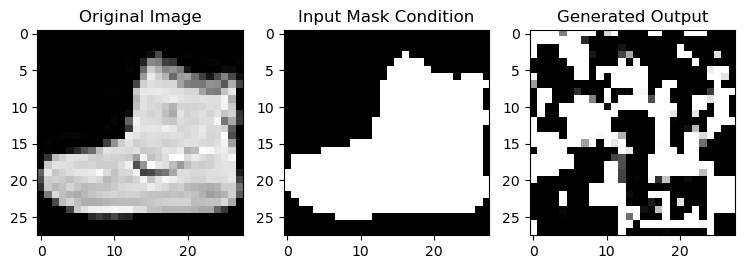

In [20]:
@torch.no_grad()
def sample_conditioned(model, ae, action_encoder, seg_encoder, mask, action):
    model.eval()
    ae.eval()
    
    # Process static conditions
    mask_emb = seg_encoder(mask.unsqueeze(0).to(device))
    action_emb = action_encoder(action.unsqueeze(0).to(device))
    
    # Initialize from pure noise in latent space (Shape matches encoder: 1, 4, 7, 7)
    z = torch.randn((1, 4, 7, 7)).to(device)
    
    # Iterative reverse diffusion
    for i in reversed(range(T)):
        t_tensor = torch.tensor([i], device=device).long()
        predicted_noise = model(z, t_tensor, action_emb, mask_emb)
        
        beta_t = beta[i]
        alpha_t = alpha[i]
        alpha_bar_t = alpha_bar[i]
        
        if i > 0:
            noise = torch.randn_like(z)
        else:
            noise = 0
            
        # DDPM step math equation logic
        mean = (1 / torch.sqrt(alpha_t)) * (z - ((beta_t / torch.sqrt(1 - alpha_bar_t)) * predicted_noise))
        z = mean + torch.sqrt(beta_t) * noise
        
    # Decode final output from latent to image pixel space
    generated_img = ae.decode(z)
    return generated_img.squeeze().cpu().numpy()

# Pull sample conditions from the validation sequence
test_img, test_mask, test_action, _ = train_dataset[0]

# Generate reconstruction from the parameters
generated = sample_conditioned(unet, ae_model, action_enc, seg_enc, test_mask, test_action)

# Plot Output Metrics
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(test_img.squeeze(), cmap='gray')
axes[0].set_title("Original Image")
axes[1].imshow(test_mask.squeeze(), cmap='gray')
axes[1].set_title("Input Mask Condition")
axes[2].imshow(generated, cmap='gray')
axes[2].set_title("Generated Output")
plt.show()